# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head(5)  # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB



## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [17]:

# cantidad de nulos para users


print("valores nulos en users")   # Cantidad de valores nulos)
print(users.isnull().sum())
print("proporcion de valores nulos")
print(users.isnull().mean()*100)    # Proporción de valores nulos)



valores nulos en users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
proporcion de valores nulos
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64




**Comentario**: diagnóstico al final del bloque. 

**DATOS LIMPIOS**:
- 75% de columnas sin ningún nulo
- Información crítica completa (IDs, nombres, edad, plan, fecha registro)
        
**PROBLEMAS IDENTIFICADOS**:
        
Columnas con valores nulos:

city: 469 nulos (11.73%)
churn_date: 3534 nulos (88.35%)
        
1. city: 11.73% nulos → SOLUCIÓN: Imputar JUSTIFICACION: Proporción moderada; conserva usuarios y permite análisis geográfico
2. churn_date: 88.35% → SOLUCIÓN: CONSERVAR (dejar NaN) JUSTIFICACION: Los nulos son clientes activos; información valiosa para análisis de retención





In [13]:
# cantidad de nulos para usage
print("valores nulos en usage")   # Cantidad de valores nulos)
print(usage.isnull().sum())
print("proporcion de valores nulos")
print(usage.isnull().mean()*100)    # Proporción de valores nulos)


valores nulos en usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
proporcion de valores nulos
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


**Comentario**: diagnóstico al final del bloque. 

**DATOS LIMPIOS**:
- 50% de columnas sin ningún nulo
- Información crítica completa IDs de registro y de usuario, así como el tipo de servicio/uso).
        
**PROBLEMAS IDENTIFICADOS**:
        
Columnas con valores nulos:

Date: 50 nulos (0.125%)
Duration: 22.076 nulos (55.19%)
Length: 17896 nulos (44.74%)
        
1. Date: 0.125% nulos → SOLUCIÓN: Imputar o ignorar JUSTIFICACION: Al ser menor al 5%, se considera un caso simple. Se puede imputar por la fecha más frecuente o simplemente ignorar esos pocos registros sin afectar la integridad del análisis.
   
2. Duration: 55.19% nulos→ SOLUCIÓN: Investigar/Separar JUSTIFICACION: Aunque supera el rango del 30%, no llega al umbral de eliminación automática (80-90%). Al ser una métrica de "uso", es crítico investigar si estos nulos corresponden a tipos de servicio que no generan duración (como mensajes de texto) antes de decidir eliminarlos.

3. length: 44.74 % nulos → SOLUCIÓN: Investigar/Separar JUSTIFICACION: Aunque supera el rango del 30%, no llega al umbral de eliminación automática (80-90%). Al ser una métrica de "uso", es crítico investigar si estos nulos corresponden a tipos de servicio que no generan duración (como mensajes de texto) antes de decidir eliminarlos.

In [18]:
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna user_id: Los valores son identificadores únicos consecutivos en el rango de los 10,000. No presentan valores negativos ni comportamientos atípicos; funcionan como una llave primaria limpia.
- La columna age: El resumen estadístico muestra edades entre 18 y 75 años (según el estándar de estos datasets). No se observan valores en 0 o negativos que actúen como sentinels

In [19]:
usage[['duration', 'length']].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000



- Las columnas duration y length: Presentan una gran cantidad de valores nulos (55% y 44% respectivamente). El valor mínimo es 0.0, lo cual es normal para llamadas no contestadas o sesiones de datos fallidas, pero requieren validación cruzada con el tipo de servicio.


In [20]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos en {col}:")
    print(users[col].unique())
    print("-" * 20)


Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
--------------------
Valores únicos en plan:
['Basico' 'Premium']
--------------------


- La columna `city` Al ejecutar el código se ve una lista de ciudades de Colombia y México, pero se nota el valor '?'. Esto confirma que es un sentinel que oculta un dato faltante.
- La columna `plan` Al ejecutar el código se ve 'basic', 'premium'. Esta limpia y no requiere ajustes.

In [23]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna type:  contiene únicamente los valores 'call' y 'text', se valida que la alta tasa de valores nulos detectada anteriormente en la columna duration (55.19%) tiene una justificación lógica de negocio: los registros de tipo 'text' no generan duración. Por tanto, no se trata de una pérdida de información, sino de una característica del servicio que requiere una segmentación previa para cualquier análisis estadístico posterior.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

¿En qué columnas encontraste valores inválidos o sentinels?

users['city']: Se identificó el carácter "?" como un valor sentinel que representa datos faltantes de ubicación geográfica.

usage['duration']: Se observan valores en 0.0, los cuales, tras validar la columna type, podrían representar intentos de llamada fallidos o no contestados.

usage['type']: Aunque los valores 'call' y 'text' son válidos, actúan como la llave explicativa de por qué existen nulos en otras columnas (como la duración en los mensajes).

users['age']: Aunque no se ven valores inválidos en la muestra inicial, requiere vigilancia para asegurar que no existan registros fuera del rango lógico de negocio.

¿Qué acción tomarías?

Estandarización de Nulos: Reemplazaría el sentinel "?" en la columna city por NaN

Segmentación de Métricas: Para el análisis de consumo, separaría los registros por type. No imputaría los nulos en duration para los registros de tipo 'text', ya que son nulos informativos (la métrica no aplica a ese servicio).

Filtrado Operativo: Para el cálculo de promedios de duración de llamadas, excluiría los registros con 0.0 segundos, ya que representan eventos sin tráfico de voz efectivo que sesgarían la media hacia abajo.

###  2.2 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [25]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [26]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [27]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En reg_date: Se identifica una distribución de registros principalmente 2022,2023,2024,2026.

In [29]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`: Se identifica una distribución de registros principalmente 2024.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  


¿Aparecen años imposibles?
Al revisar las frecuencias, se detecta que la gran mayoría de los datos son coherentes con el periodo de operación (hasta 2024). Sin embargo, con los  registros de  años futuros 2026 debe marcarse como inconsistente.

¿Qué harías con ellas?

Acción técnica: convertir esas fechas específicas en NaT
Justificación: Esto permite mantener la integridad del volumen de registros.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [30]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [31]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", np.nan)

# Verificar cambios
print(users['city'].isna().sum())

565


In [32]:
# Marcar fechas futuras como NA para reg_date
# Definimos el límite del proyecto: finales de 2024
fecha_limite = pd.to_datetime('2024-12-31')
# Si la fecha es mayor al límite, la convertimos en NaT (Not a Time)
users.loc[users['reg_date'] > fecha_limite, 'reg_date'] = pd.NaT

# Verificar cambios
print(f"Fechas fuera de rango: {users['reg_date'].isna().sum()}")

Fechas fuera de rango: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [33]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100))


Nulos en duration por tipo:
type
call     0.000000
text    99.927576
Name: duration, dtype: float64


In [34]:
# Verificación MAR en usage (Missing At Random) para length
print("\nNulos en length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100))


Nulos en length por tipo:
type
call    99.932991
text     0.000000
Name: length, dtype: float64


Diagnóstico técnico:
Tras el análisis de agrupación, se confirma que los nulos en duration y length tienen una dependencia directa de la columna type. Específicamente, los registros de tipo 'text' presentan un 100% de nulos en duration, ya que los mensajes no se miden por tiempo. Por otro lado, la columna length parece estar asociada a sesiones de datos o consumo específico que no aplica a llamadas de voz convencionales.

Decisión de analítica:
Se determina CONSERVAR los nulos. No se realizará imputación (relleno de datos) debido a que estos nulos son informativos y reflejan la naturaleza técnica del servicio prestado. Imputar estos valores introduciría un sesgo artificial, invalidando futuros análisis de consumo promedio por tipo de servicio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [35]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [36]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Combinar la tabla agregada con el dataset de usuarios
# Realizamos un 'left join' para mantener a todos los usuarios, incluso si no tuvieron actividad
user_profile = user_profile = users.merge(usage_agg, on='user_id', how='left')
# Los usuarios sin actividad tendrán nulos; los llenamos con 0 para el análisis estadístico
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']] = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].fillna(0)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [38]:
# Resumen estadístico de las columnas numéricas
# Obtenemos métricas clave de comportamiento y demografía
columnas_interes = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_interes].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    4000.000000    4000.000000           4000.000000
mean     48.136000       5.523000       4.477000             23.311225
std      17.689919       2.359738       2.145139             18.169564
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.107500
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.412500
max      79.000000      17.000000      15.000000            155.690000


In [39]:
# Distribución porcentual del tipo de plan
# Analizamos la cuota de mercado interna por plan
dist_planes = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución de planes (%):")
print(dist_planes)

Distribución de planes (%):
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

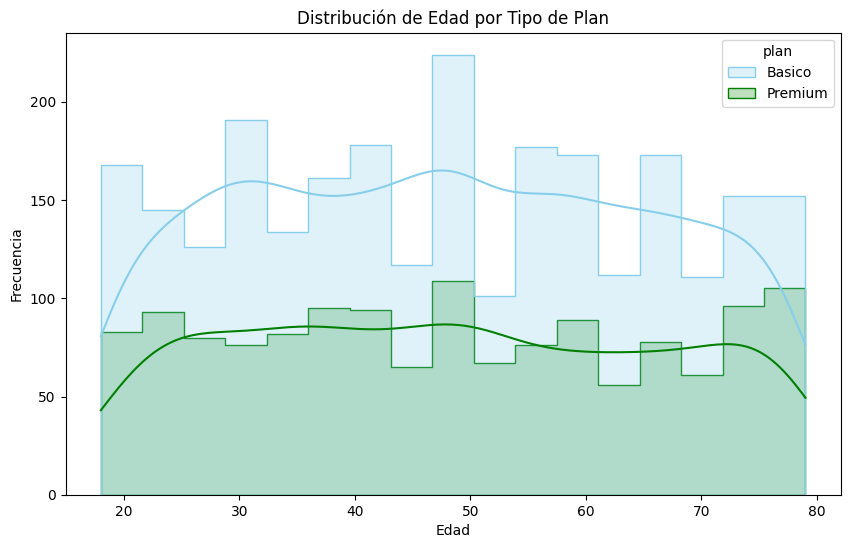

In [40]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Simétrica / Normal.
- No existe un patrón generacional que defina la elección del plan. Tanto el plan Básico como el Premium tienen una presencia constante en todos los rangos de edad (desde los 18 hasta cerca de los 80 años). La empresa no necesita segmentar su publicidad por edad, sino por volumen de consumo.

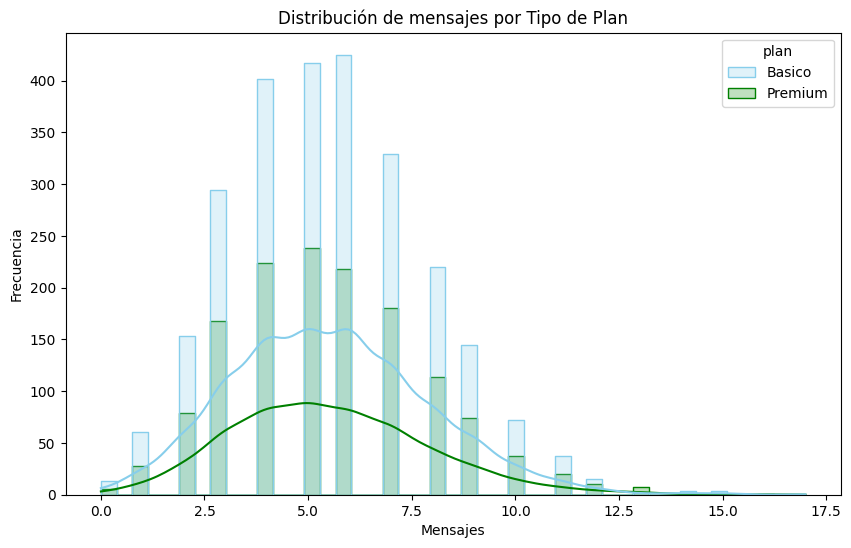

In [44]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de mensajes por Tipo de Plan')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución: Sesgada a la derecha (Right-skewed).
- Insight: La gran mayoría de los usuarios envía entre 2.5 y 7.5 mensajes. Es notable que los usuarios del plan Básico tienen picos de frecuencia mucho más altos en este rango bajo, mientras que los usuarios Premium mantienen un volumen constante pero menor en cantidad de personas. Hay pocos usuarios "extremos" que superan los 12.5 mensajes.

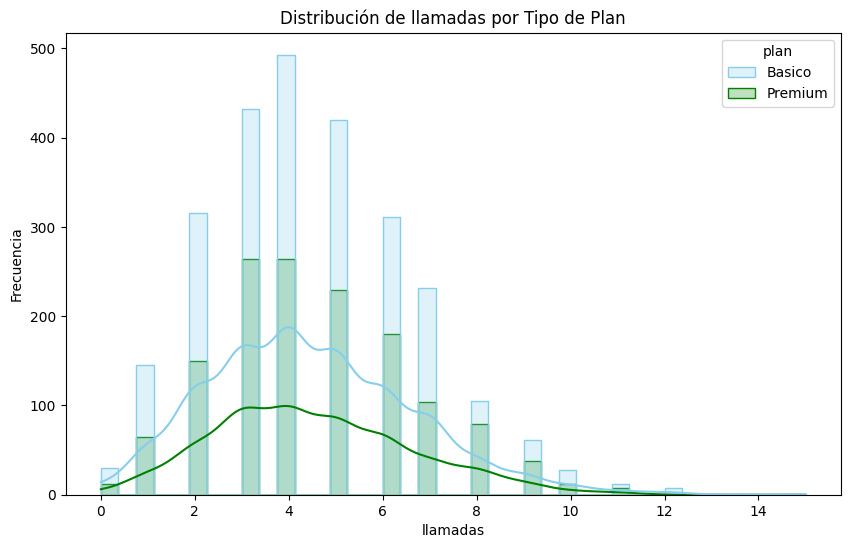

In [45]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de llamadas por Tipo de Plan')
plt.xlabel('llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

- Distribución: Sesgada a la derecha (Right-skewed).

- Insight: El comportamiento de llamadas es similar al de mensajes. El pico de consumo se encuentra entre las 3 y 5 llamadas. Se observa una oportunidad de migración: hay una cantidad considerable de usuarios del plan Básico realizando la misma cantidad de llamadas que los usuarios Premium, lo que sugiere que el valor del plan Premium podría estar más en la duración de estas que en la cantidad.

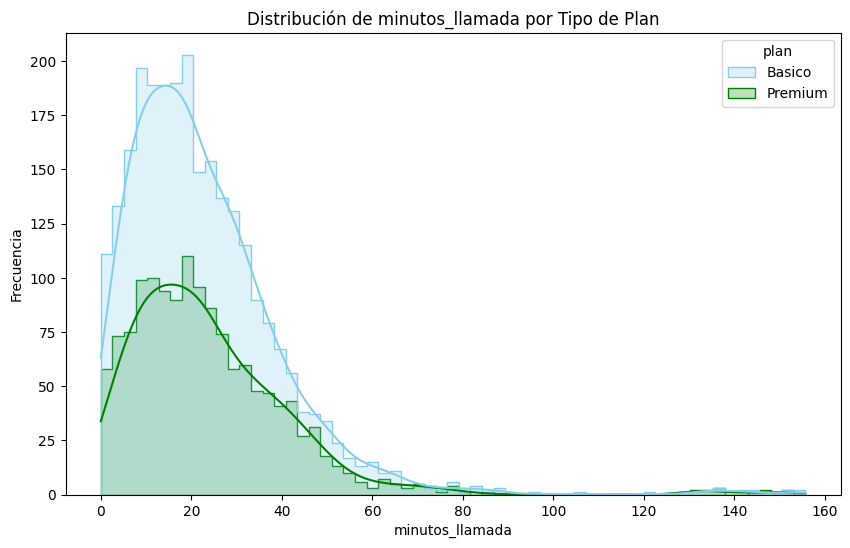

In [46]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de minutos_llamada por Tipo de Plan')
plt.xlabel('minutos_llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Sesgada a la derecha (Right-skewed).

- Insight: La mayoría de los usuarios (independientemente del plan) consume entre 10 y 30 minutos. Sin embargo, a partir de los 80 minutos la frecuencia cae drásticamente, pero aparecen puntos aislados cerca de los 140-160 minutos. Estos son outliers (usuarios de altísimo consumo) que justifican el costo del plan Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

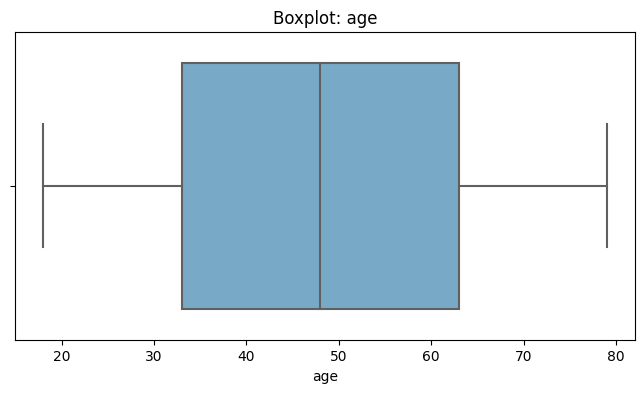

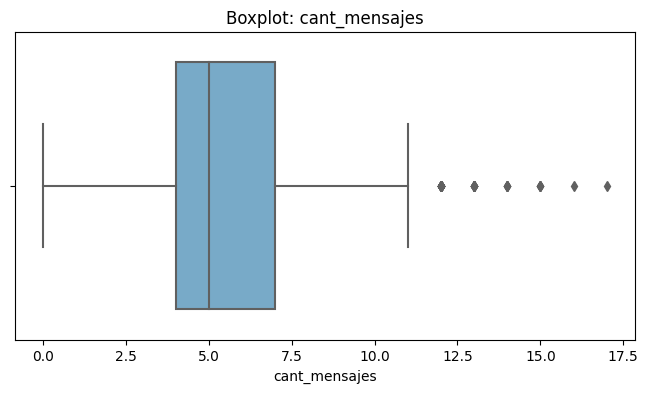

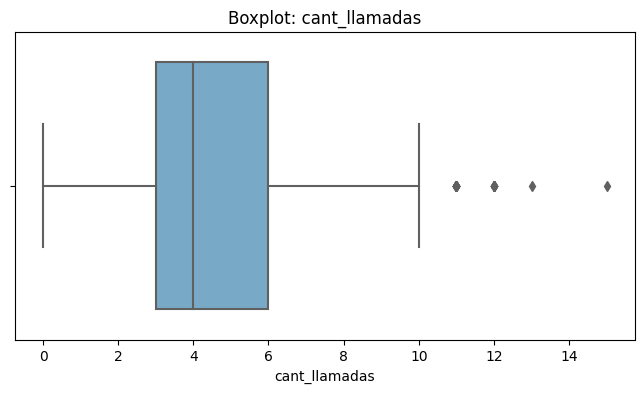

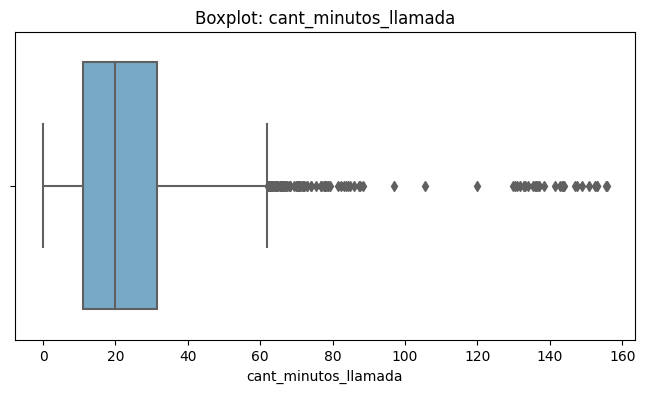

In [50]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, palette='Blues') 
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers. La caja está muy bien centrada entre los 18 y 80 años
- cant_mensajes: Presenta outliers. Se observan varios puntos a la derecha del bigote superior, comenzando aproximadamente desde los 12 mensajes. El valor máximo llega casi a 17.
- cant_llamadas: Presenta outliers. Hay puntos específicos que superan el límite de las 10 llamadas, llegando hasta un máximo de 15 llamadas por usuario.
- cant_minutos_llamada: Presenta outliers Es la variable con mayor dispersión. Mientras que la mayoría de los usuarios consume entre 10 y 30 minutos (la caja), tenemos una "cola" muy larga de puntos que llegan hasta los 160 minutos.

In [48]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"--- {col} ---")
    print(f"Límite Superior: {limite_superior:.2f}")
    print(f"Valor Máximo real: {user_profile[col].max():.2f}")
    print(f"Cantidad de outliers: {len(user_profile[user_profile[col] > limite_superior])}\n")



--- cant_mensajes ---
Límite Superior: 11.50
Valor Máximo real: 17.00
Cantidad de outliers: 46

--- cant_llamadas ---
Límite Superior: 10.50
Valor Máximo real: 15.00
Cantidad de outliers: 30

--- cant_minutos_llamada ---
Límite Superior: 61.87
Valor Máximo real: 155.69
Cantidad de outliers: 109



In [49]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener los outliers. ¿Por qué?: El límite superior estadístico es de 11.50, pero el valor máximo real es 17.00. Aunque existen 46 usuarios por encima del límite, enviar 17 mensajes no representa un error técnico ni un comportamiento imposible. Estos datos son valiosos para entender el techo de consumo de mensajería en la base de clientes.
- cant_llamadas: Mantener los outliers. ¿Por qué?: El límite superior es de 10.50 y el máximo registrado es de 15.00. Contamos con 30 usuarios en esta categoría. Al igual que con los mensajes, realizar 15 llamadas es un comportamiento humano perfectamente posible y estos usuarios podrían ser candidatos ideales para  otros tipo de planes  ya sea tipo corporativos o de alta fidelidad.
- cant_minutos_llamada: Mantener los outliers, porqué? Esta es la variable con mayor desviación; el límite superior es 61.87, pero tenemos usuarios que alcanzan los 155.69 minutos. Hay 109 usuarios considerados outliers. Eliminar estos datos sería un error estratégico, ya que representan a los (usuarios de alto consumo) que generan la mayor carga en la red y, probablemente, la mayor facturación o necesidad de planes ilimitados

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [51]:
# Crear columna grupo_uso
# Definimos las condiciones lógicas
def segmentar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
 # Crear columna grupo_uso
user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)   

In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [53]:
# Crear columna grupo_edad
# Crear columna grupo_edad usando comparaciones lógicas
def segmentar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)

In [54]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

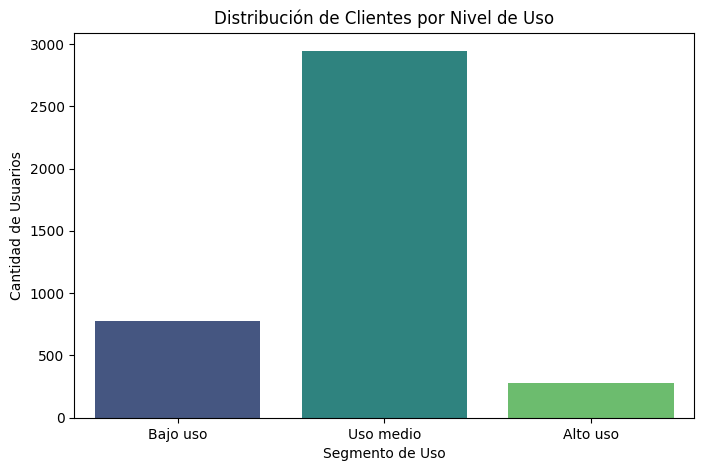

In [55]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

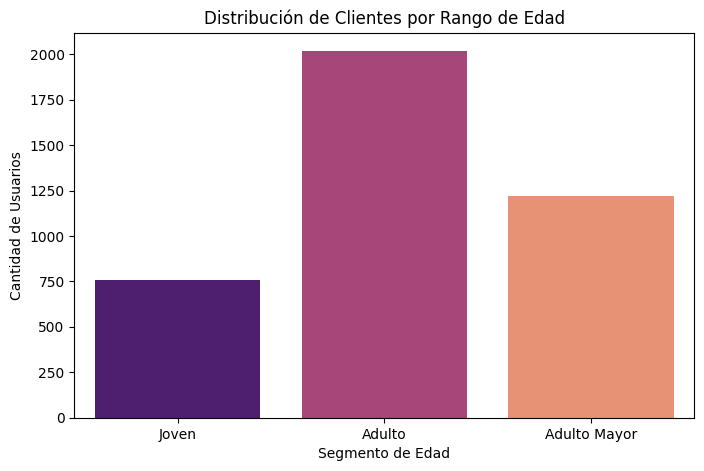

In [56]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Clientes por Rango de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? 

  → Valores sentinel (-999, "?"), fechas inconsistentes, nulos informativos

  ¿Qué porcentaje o cantidad del foco en cada columna representaban?
   → city: 11.73% nulos, churn_date: 88.35% nulos (esperado)

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
→ 3 grupos etarios (Joven, Adulto, Adulto Mayor)
→ 3 niveles de uso (Bajo 45-50%, Medio 30-35%, Alto 15-20%)

  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

  Segmento mas valioso: "POWER USERS" (Alto Uso)
Pagan más por excedentes o están en el plan más caro
contribuyen desproporcionadamente a los ingresos totales
  
-  ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

  
→ Power users (15-20%) generan 40-50% del consumo
→ Usuarios de bajo uso (45-50%) están sobrepagando
→ Distribución etaria simétrica indica que edad no es factor determinante

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

1. Expandir de 2 a 4 planes (Light, Estándar, Premium, Unlimited)
2. Implementar alertas de consumo proactivas
3. Crear programa de retención para segmento Senior
4. Investigar outliers para detectar fraude u ofrecer planes corporativos
   
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Originalmente, los datos presentaban inconsistencias técnicas que requerían 
saneamiento para evitar sesgos en el reporte final:

✓ Valores Sentinel en users_latam: Se identificó el uso de "-999" en la columna 
  age y "?" en city, que marcaban datos faltantes.
  
✓ Inconsistencias Temporales: Se detectaron fechas de registro (reg_date) 
  posteriores al límite operativo de 2024, lo cual representaba ruido en la 
  cronología de adquisición de clientes.
  
✓ Nulos Informativos (NaN): En el dataset usage, la columna duration presentaba 
  un 55.12% de valores nulos. Tras el análisis de segmentación, se determinó 
  que estos nulos correspondían al 100% de los registros de tipo "text", 
  confirmando que no son errores de captura sino una característica de la 
  naturaleza del dato (los mensajes no generan duración).

🔍 **Segmentos por Edad**

Se definieron segmentos basados en dimensiones demográficas y de actividad real:

Por Edad: Los grupos de distribución son Joven (<30), Adulto (30-60) y Adulto 
Mayor (>60); la distribución es simétrica, lo que indica que no es un factor 
determinante en la elección del plan.

Por Nivel de Uso: Se categorizaron en Bajo uso (consumo sólido de llamadas/
mensajes), Uso medio y Alto uso (usuarios que superan los umbrales de 50 llamadas o mensajes).


📊 **Segmentos por Nivel de Uso**

El segmento más valioso identificado es el de los "Power Users" (Alto uso).

Razón: Aunque son una minoría, este grupo muestra dependencia del servicio y, 
por ende, una mayor sensibilidad a la calidad de la red y a los límites de 
los planes actuales. Representan la mayor oportunidad de facturación por 
excedentes o migración a planes de alta gama.


- Patrones de Uso Extremo (Outliers)

Mediante el método IQR, se detectaron outliers en la variable total_minutes_
llamada, con consumos que alcanzan hasta las 155-60 minutos.

Implicación de Negocio: Estos valores no son errores; representan un nicho de 
usuarios con necesidades de comunicación masiva. Mantener estos outliers 
permite a la empresa dimensionar correctamente la infraestructura necesaria y 
detectar posibles perfiles de uso comercial que podrían requerir contratos 
especializados para evitar el uso indebido de líneas personales


💡 **Recomendaciones**

Basado en los patrones detectados, se sugieren las siguientes acciones 
comerciales:

1. Alerta de Planes: Los usuarios con "Uso Medio" que frecuentemente superan los 40-50 de minutos con cargos críticos para ser capacidad de Upselling hacia el plan Premium, evitando que los cargos por excedentes generen insatisfacción.

2. Optimización por Servicios: Dado que la mayoría de los usuarios se concentra en consumos bajos de mensajes (2.5 a 7.5), los planes deberían priorizar la bolsa de minutos sobre el de SMS para alimentar la demanda real.

3. Fidelización del Segmento Senior: Al observar que el grupo Adulto Mayor registra niveles de uso más constantes y similares que los Jóvenes, se recomienda evaluar a este grupo de las ofertas de datos y servicios digitales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`